In [ ]:
import os
import glob
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\AnneB\Downloads\Alzheimer MRI Detection\src\Data"

ModuleNotFoundError: No module named 'nibabel'

In [1]:
import os
data_dir = r"C:\Users\AnneB\Downloads\Alzheimer MRI Detection\src\Data"  # ajuste si besoin
print(os.listdir(data_dir))

# puis un cran plus profond sur le premier sujet trouvé
first = os.listdir(data_dir)[0]
print(os.listdir(os.path.join(data_dir, first)))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\AnneB\\Downloads\\Alzheimer MRI Detection\\src\\Data'

In [2]:
def inventory_subjects(data_dir=DATA_DIR):
    """Parcourt Data/ récursivement et trouve tous les sujets OAS1_*_MR1,
    quelle que soit la profondeur d'imbrication des dossiers disc*."""
    subjects = []
    pattern = os.path.join(data_dir, "**", "OAS1_*_MR1")
    for subj_path in sorted(glob.glob(pattern, recursive=True)):
        subj_id = os.path.basename(subj_path)
        t88_path = os.path.join(subj_path, "PROCESSED", "MPRAGE", "T88_111")
        fsl_seg_path = os.path.join(subj_path, "FSL_SEG")
        subjects.append({
            "subject_id": subj_id,
            "path": subj_path,
            "has_T88": os.path.isdir(t88_path),
            "has_FSL_SEG": os.path.isdir(fsl_seg_path),
        })
    return pd.DataFrame(subjects)

In [4]:
# --- 2. Fusion avec les métadonnées cliniques --------------------------

def find_clinical_file(data_dir=DATA_DIR):
    """Repère le fichier clinique quel que soit son nom exact (suffixe hash variable)."""
    candidates = glob.glob(os.path.join(data_dir, "oasis_cross-sectional*.csv")) + \
                 glob.glob(os.path.join(data_dir, "oasis_cross-sectional*.xlsx"))
    return candidates[0] if candidates else None


def load_clinical_data(path):
    """Charge le fichier clinique (age, sexe, CDR, MMSE, eTIV, nWBV, ASF), csv ou xlsx."""
    if path.endswith(".xlsx"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    return df


def merge_inventory_clinical(inventory_df, clinical_df):
    clinical_df = clinical_df.rename(columns={"ID": "subject_id"})
    merged = inventory_df.merge(clinical_df, on="subject_id", how="left")
    return merged


In [5]:
# --- 3. Chargement et visualisation d'un volume ------------------------

def load_volume(subject_path):
    """Charge le volume T88 normalisé (.img/.hdr ou .nii selon la release)."""
    t88_dir = os.path.join(subject_path, "PROCESSED", "MPRAGE", "T88_111")
    candidates = glob.glob(os.path.join(t88_dir, "*.img")) + \
                 glob.glob(os.path.join(t88_dir, "*.nii*"))
    if not candidates:
        raise FileNotFoundError(f"Aucun volume trouvé dans {t88_dir}")
    img = nib.load(candidates[0])
    data = np.squeeze(img.get_fdata())  # retire les dimensions singleton (ex: (176,208,176,1))
    return data, img.affine


def show_three_planes(volume, title="Coupes du volume"):
    """Affiche les 3 plans anatomiques au centre du volume."""
    x, y, z = [s // 2 for s in volume.shape]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(volume[x, :, :].T, cmap="gray", origin="lower")
    axes[0].set_title("Sagittal")
    axes[1].imshow(volume[:, y, :].T, cmap="gray", origin="lower")
    axes[1].set_title("Coronal")
    axes[2].imshow(volume[:, :, z].T, cmap="gray", origin="lower")
    axes[2].set_title("Axial")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

Inventaire des sujets...
485 sujets trouvés.
      subject_id                                               path  has_T88  \
0  OAS1_0349_MR1  C:\Users\AnneB\Downloads\Alzheimer MRI Detecti...     True   
1  OAS1_0350_MR1  C:\Users\AnneB\Downloads\Alzheimer MRI Detecti...     True   
2  OAS1_0351_MR1  C:\Users\AnneB\Downloads\Alzheimer MRI Detecti...     True   
3  OAS1_0352_MR1  C:\Users\AnneB\Downloads\Alzheimer MRI Detecti...     True   
4  OAS1_0353_MR1  C:\Users\AnneB\Downloads\Alzheimer MRI Detecti...     True   

   has_FSL_SEG  
0         True  
1         True  
2         True  
3         True  
4         True  

Chargement des données cliniques...
Fichier clinique trouvé : C:\Users\AnneB\Downloads\Alzheimer MRI Detection\src\Data\oasis_cross-sectional-5708aa0a98d82080.xlsx

Répartition CDR (0=sain, 0.5=MCI/très léger, 1=léger, 2=modéré) :
CDR
0.0    151
0.5     82
1.0     35
2.0      2
NaN    215
Name: count, dtype: int64

Exemple de chargement d'un volume (premier sujet avec 

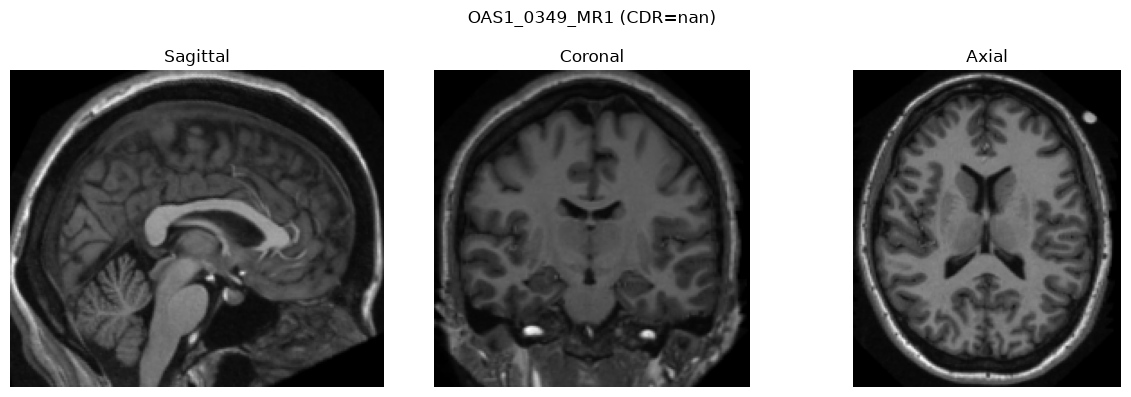


Inventaire complet sauvegardé : inventaire_oasis1.csv


In [7]:
# --- 4. Exécution --------------------------------------------------------

print("Inventaire des sujets...")
inv = inventory_subjects()
print(f"{len(inv)} sujets trouvés.")
print(inv.head())

print("\nChargement des données cliniques...")
clinical_path = find_clinical_file()
if clinical_path:
    print("Fichier clinique trouvé :", clinical_path)
    clinical = load_clinical_data(clinical_path)
    full = merge_inventory_clinical(inv, clinical)
    print("\nRépartition CDR (0=sain, 0.5=MCI/très léger, 1=léger, 2=modéré) :")
    print(full["CDR"].value_counts(dropna=False).sort_index())
else:
    print("Fichier clinique introuvable dans Data/ — vérifie qu'il y est bien copié.")
    full = inv.copy()
    full["CDR"] = None

print("\nExemple de chargement d'un volume (premier sujet avec T88 disponible)...")
example = full[full["has_T88"]].iloc[0]
volume, affine = load_volume(example["path"])
print(f"Sujet : {example['subject_id']} | forme du volume : {volume.shape}")
show_three_planes(volume, title=f"{example['subject_id']} (CDR={example['CDR']})")

full.to_csv("inventaire_oasis1.csv", index=False)
print("\nInventaire complet sauvegardé : inventaire_oasis1.csv")